# Análisis comparativo: base vs. afinada (LoRA) vs. RAG

Este notebook parte de `eval_crobotp_base_vs_finetuned_vs_rag.csv` (ya trae
las 98 preguntas del split de test con las 3 respuestas y su `rougeL` por
ejemplo) y responde las preguntas que realmente importan para el informe
del taller:

1. **¿Quién gana en las métricas automáticas?** (ROUGE completo + BERTScore,
   recalculados aquí para tener rouge1/2/Lsum y BERTScore que el CSV no trae).
2. **¿La diferencia es estadísticamente significativa** o podría ser ruido?
   (test de Wilcoxon pareado, apropiado porque ROUGE no es normal).
3. **¿Por qué gana quien gana?** -se cuantifican dos posibles explicaciones
   antes de sacar conclusiones apresuradas:
   - Las referencias de `qa.jsonl` traen tags `[cite: N]` pegados -¿afecta
     eso el ROUGE de forma pareja o desnivela la cancha?
   - RAG tiene una tasa de **rechazo** ("no puedo responder con este
     contexto") -¿cuánto pesa eso en el promedio?
4. **Casos ganados/perdidos**: ejemplos concretos para citar en la discusión.
5. **Diagnóstico del retrieval**: qué tan seguido RAG cita varios manuales
   a la vez, y si eso correlaciona con peor desempeño.


## 0. Instalar dependencias

In [41]:
%pip install pandas numpy matplotlib scipy rouge_score bert_score

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuración

In [42]:
import os

# Ruta al CSV fusionado que produjo rag_gemma.ipynb (seccion 13)
MERGED_CSV = "eval_crobotp_base_vs_finetuned_vs_rag.csv"

# Carpeta donde se guardan las figuras y el resumen final de este analisis
ANALYSIS_DIR = "./resultados/analisis"
os.makedirs(ANALYSIS_DIR, exist_ok=True)

BERTSCORE_LANG = "en"  # el dataset esta en ingles

print(f"CSV de entrada: {os.path.abspath(MERGED_CSV)}")
print(f"Salidas de este analisis en: {os.path.abspath(ANALYSIS_DIR)}")


CSV de entrada: d:\OneDrivePersonal\OneDrive\Maestria\Semestre 3\NLP\VDI\Ft_Rag\resultados\eval_crobotp_base_vs_finetuned_vs_rag.csv
Salidas de este analisis en: d:\OneDrivePersonal\OneDrive\Maestria\Semestre 3\NLP\VDI\Ft_Rag\resultados\resultados\analisis


## 2. Cargar y revisar los datos

In [43]:
import pandas as pd

df = pd.read_csv(MERGED_CSV)
print(f"Filas: {len(df)}  |  Columnas: {list(df.columns)}")

faltantes = df.isna().sum()
if faltantes.any():
    print("\nAviso -valores faltantes por columna:")
    print(faltantes[faltantes > 0])
else:
    print("\nSin valores faltantes.")

df.head(3)


Filas: 98  |  Columnas: ['pregunta', 'referencia', 'respuesta_rag', 'fuentes_rag', 'rougeL_rag', 'respuesta_base', 'respuesta_afinada', 'rougeL_base', 'rougeL_afinado']

Sin valores faltantes.


,pregunta,referencia,respuesta_rag,fuentes_rag,rougeL_rag,respuesta_base,respuesta_afinada,rougeL_base,rougeL_afinado
0,What role do M components play in the PLC system?,They serve as internal auxiliary relays for lo...,The text states that M components are internal...,PLC__User_Manual_final__v2 p.5; CRP_programmin...,0.063492,M components play a key role in the PLC system...,M components are internal auxiliary relays.,0.028986,0.352941
1,What ambient humidity level is required for op...,20% to 85% relative humidity with no condensat...,The text states that the ambient humidity leve...,EN-00001-A1_Robot_Operation_Manual__1 p.12; CR...,0.148148,The optimal ambient humidity level for operati...,20% to 85% relative humidity with no condensat...,0.042553,1.000000
2,What stack command pushes current boolean stat...,MPS[cite: 6].,The text does not specify a stack command to p...,PLC__User_Manual_final__v2 p.4; PLC__User_Manu...,0.000000,The answer is STSB (Store Boolean Status) comm...,The MRD stack command[cite: 6].,0.000000,0.444444


## 3. Limpieza de referencias -tags `[cite: N]`

`qa.jsonl` trae referencias como `"...for logic processing[cite: 6]."` -ese
tag no lo va a reproducir NINGUN modelo, asi que penaliza el ROUGE de las
3 columnas por igual. Se limpia para tener una version "justa" y se
compara contra la version cruda, para saber si esto cambia el orden de los
resultados o solo el nivel absoluto.


In [44]:
import re

def limpiar_referencia(texto):
    return re.sub(r"\s*\[cite:\s*\d+\]", "", str(texto)).strip()

df["referencia_limpia"] = df["referencia"].apply(limpiar_referencia)

n_con_tag = (df["referencia"] != df["referencia_limpia"]).sum()
print(f"Referencias con tag [cite: N]: {n_con_tag} / {len(df)} ({100*n_con_tag/len(df):.1f}%)")
print()
print("Antes: ", df.loc[df['referencia'] != df['referencia_limpia'], 'referencia'].iloc[0])
print("Despues:", df.loc[df['referencia'] != df['referencia_limpia'], 'referencia_limpia'].iloc[0])


Referencias con tag [cite: N]: 70 / 98 (71.4%)

Antes:  They serve as internal auxiliary relays for logic processing[cite: 6].
Despues: They serve as internal auxiliary relays for logic processing.


## 4. Recalcular ROUGE completo + BERTScore por enfoque

El CSV solo trae `rougeL` por fila. Aqui se recalcula ROUGE-1/2/L/Lsum y
BERTScore para los 3 enfoques, con referencia CRUDA y LIMPIA, para poder
reportar el numero completo y saber cuanto pesa el tag `[cite: N]`.


In [45]:
from rouge_score import rouge_scorer
import numpy as np

# rouge_score es 100% local -no necesita internet, a diferencia de evaluate.load("rouge")
_rouge_scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL", "rougeLsum"], use_stemmer=True)

def rouge_completo(preds, refs):
    acumulado = {"rouge1": [], "rouge2": [], "rougeL": [], "rougeLsum": []}
    for pred, ref in zip(preds, refs):
        s = _rouge_scorer.score(ref, pred)  # (referencia, prediccion)
        for k in acumulado:
            acumulado[k].append(s[k].fmeasure)
    return {k: float(np.mean(v)) for k, v in acumulado.items()}

# BERTScore SI necesita descargar un modelo (roberta-large u otro) la primera
# vez -si tu red bloquea eso, se salta con un aviso y el resto del notebook
# sigue funcionando solo con ROUGE. Ponlo en False para saltarlo directamente
# sin siquiera intentarlo.
CALCULAR_BERTSCORE = True

def bertscore_f1(preds, refs):
    if not CALCULAR_BERTSCORE:
        return float("nan")
    try:
        from bert_score import score as bert_score_fn
        _, _, F1 = bert_score_fn(preds, refs, lang=BERTSCORE_LANG, verbose=False)
        return float(F1.mean())
    except Exception as e:
        print(f"Aviso: no se pudo calcular BERTScore ({type(e).__name__}: {e}).")
        print("Se continua el analisis solo con ROUGE -puedes correr esta parte")
        print("despues en GCP, donde si hay internet, o revisar tu conexion.")
        return float("nan")

ENFOQUES = {
    "base": "respuesta_base",
    "afinado": "respuesta_afinada",
    "rag": "respuesta_rag",
}

def calcular_metricas(preds, refs):
    r = rouge_completo(preds, refs)
    r["bertscore_f1"] = bertscore_f1(preds, refs)
    r["longitud_promedio_palabras"] = sum(len(str(p).split()) for p in preds) / len(preds)
    return r

filas_resumen = []
for nombre, col in ENFOQUES.items():
    print(f"Calculando metricas para: {nombre}...")
    m_crudo = calcular_metricas(df[col].astype(str).tolist(), df["referencia"].astype(str).tolist())
    m_limpio = calcular_metricas(df[col].astype(str).tolist(), df["referencia_limpia"].astype(str).tolist())
    filas_resumen.append({
        "modelo": nombre,
        "rouge1_crudo": m_crudo["rouge1"], "rouge1_limpio": m_limpio["rouge1"],
        "rouge2_crudo": m_crudo["rouge2"], "rouge2_limpio": m_limpio["rouge2"],
        "rougeL_crudo": m_crudo["rougeL"], "rougeL_limpio": m_limpio["rougeL"],
        "rougeLsum_crudo": m_crudo["rougeLsum"], "rougeLsum_limpio": m_limpio["rougeLsum"],
        "bertscore_f1_crudo": m_crudo["bertscore_f1"], "bertscore_f1_limpio": m_limpio["bertscore_f1"],
        "longitud_promedio_palabras": m_crudo["longitud_promedio_palabras"],
    })

df_resumen = pd.DataFrame(filas_resumen).set_index("modelo")
df_resumen.to_csv(os.path.join(ANALYSIS_DIR, "metricas_resumen.csv"))
df_resumen.round(4)


Calculando metricas para: base...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,rouge1_crudo,rouge1_limpio,rouge2_crudo,rouge2_limpio,rougeL_crudo,rougeL_limpio,rougeLsum_crudo,rougeLsum_limpio,bertscore_f1_crudo,bertscore_f1_limpio,longitud_promedio_palabras
modelo,,,,,,,,,,,
base,0.0844,0.0861,0.0176,0.0179,0.0712,0.0740,0.0734,0.0761,0.8119,0.8415,82.3163
afinado,0.7161,0.5310,0.5527,0.3096,0.7049,0.5194,0.7049,0.5194,0.9487,0.8953,6.8571
rag,0.1571,0.1630,0.0595,0.0625,0.1388,0.1445,0.1397,0.1454,0.8354,0.8646,24.4694


## 5. Significancia estadística (Wilcoxon pareado)

Los 3 enfoques se evaluaron sobre las MISMAS 98 preguntas -eso permite un
test pareado (mas potente que comparar promedios sueltos). Se usa Wilcoxon
signed-rank en vez de un t-test pareado porque ROUGE no sigue una
distribución normal (muchos ceros, cola larga).


In [46]:
from scipy.stats import wilcoxon

pares = [
    ("afinado", "base", "rougeL_afinado", "rougeL_base"),
    ("rag", "base", "rougeL_rag", "rougeL_base"),
    ("afinado", "rag", "rougeL_afinado", "rougeL_rag"),
]

print("Test de Wilcoxon pareado sobre rougeL (H0: no hay diferencia entre los dos enfoques)\n")
resultados_wilcoxon = []
for nombre_a, nombre_b, col_a, col_b in pares:
    stat, p = wilcoxon(df[col_a], df[col_b])
    significativo = "SI" if p < 0.05 else "NO"
    resultados_wilcoxon.append({"comparacion": f"{nombre_a} vs {nombre_b}", "estadistico": stat,
                                 "p_valor": p, "significativo_p<0.05": significativo})
    print(f"{nombre_a:8s} vs {nombre_b:8s}  ->  p = {p:.2e}   significativo: {significativo}")

pd.DataFrame(resultados_wilcoxon).to_csv(os.path.join(ANALYSIS_DIR, "wilcoxon.csv"), index=False)


Test de Wilcoxon pareado sobre rougeL (H0: no hay diferencia entre los dos enfoques)

afinado  vs base      ->  p = 2.05e-17   significativo: SI
rag      vs base      ->  p = 1.68e-05   significativo: SI
afinado  vs rag       ->  p = 4.41e-17   significativo: SI


## 6. Tasa de rechazo de RAG

Cuando el contexto recuperado no trae el dato, el prompt le pide al modelo
que diga que no sabe. Aqui se mide cuánto pasa eso y cuánto le cuesta en
ROUGE -para distinguir "RAG responde mal" de "RAG se abstiene".


In [47]:
PATRONES_RECHAZO = r"cannot answer|does not specify|do not know|not contained in the context|i don't know|unable to answer"

df["rag_rechazo"] = df["respuesta_rag"].str.contains(PATRONES_RECHAZO, case=False, na=False, regex=True)

n_rechazo = df["rag_rechazo"].sum()
print(f"Respuestas RAG con patron de rechazo: {n_rechazo} / {len(df)} ({100*n_rechazo/len(df):.1f}%)")
print()
print(f"rougeL_rag promedio SI hubo rechazo    : {df.loc[df['rag_rechazo'], 'rougeL_rag'].mean():.4f}")
print(f"rougeL_rag promedio NO hubo rechazo    : {df.loc[~df['rag_rechazo'], 'rougeL_rag'].mean():.4f}")
print(f"rougeL_rag promedio general (con rechazo incluido): {df['rougeL_rag'].mean():.4f}")

# Cuanto subiria el promedio de RAG si se excluyen los rechazos (referencia,
# NO se recomienda excluirlos del reporte final -es informativo nada mas)
print(f"\n(hipotetico) rougeL_rag promedio EXCLUYENDO rechazos: "
      f"{df.loc[~df['rag_rechazo'], 'rougeL_rag'].mean():.4f}  "
      f"vs. afinado: {df['rougeL_afinado'].mean():.4f}")


Respuestas RAG con patron de rechazo: 47 / 98 (48.0%)

rougeL_rag promedio SI hubo rechazo    : 0.0656
rougeL_rag promedio NO hubo rechazo    : 0.1950
rougeL_rag promedio general (con rechazo incluido): 0.1330

(hipotetico) rougeL_rag promedio EXCLUYENDO rechazos: 0.1950  vs. afinado: 0.6974


## 7. Gráfico comparativo de métricas (barras)

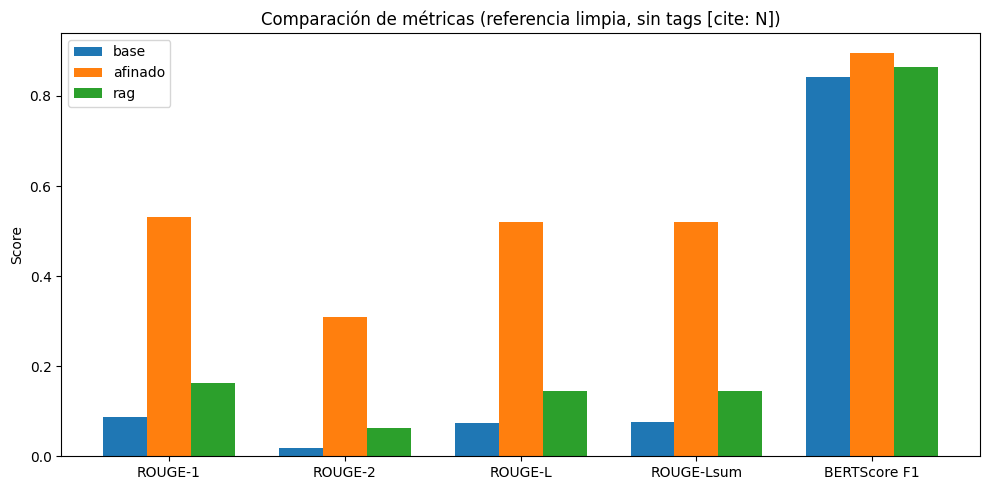

In [48]:
import matplotlib.pyplot as plt
import numpy as np

metricas_a_graficar = ["rouge1_limpio", "rouge2_limpio", "rougeL_limpio", "rougeLsum_limpio", "bertscore_f1_limpio"]
etiquetas = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum", "BERTScore F1"]

x = np.arange(len(metricas_a_graficar))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, modelo in enumerate(["base", "afinado", "rag"]):
    valores = df_resumen.loc[modelo, metricas_a_graficar].values.astype(float)
    ax.bar(x + (i - 1) * width, valores, width, label=modelo)

ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylabel("Score")
ax.set_title("Comparación de métricas (referencia limpia, sin tags [cite: N])")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "comparacion_metricas.png"), dpi=150)
plt.show()


## 8. Distribución de rougeL por enfoque (boxplot)

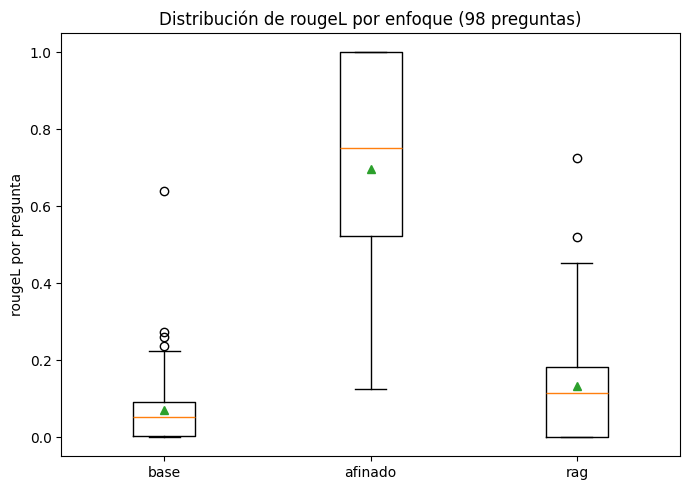

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    [df["rougeL_base"], df["rougeL_afinado"], df["rougeL_rag"]],
    tick_labels=["base", "afinado", "rag"],
    showmeans=True,
)
ax.set_ylabel("rougeL por pregunta")
ax.set_title("Distribución de rougeL por enfoque (98 preguntas)")
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "boxplot_rougeL.png"), dpi=150)
plt.show()


## 9. Verbosidad: longitud de respuesta vs. referencia

Las referencias de `qa.jsonl` son cortas (estilo "resumen ejecutivo"). Si
un enfoque genera respuestas mucho mas largas, eso perjudica el ROUGE aunque
el contenido sea correcto -vale la pena mostrarlo aparte del ROUGE.


Longitud promedio (palabras):
longitud_referencia     6.5
longitud_base          82.3
longitud_afinado        6.9
longitud_rag           24.5
dtype: float64


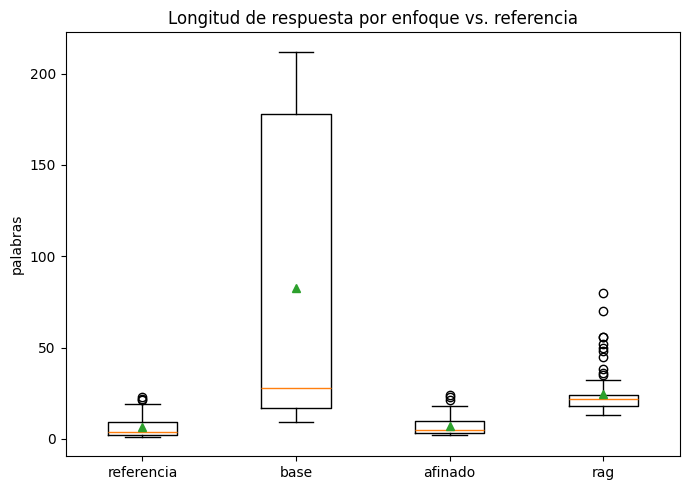

In [50]:
for col, nombre in [("respuesta_base", "base"), ("respuesta_afinada", "afinado"), ("respuesta_rag", "rag")]:
    df[f"longitud_{nombre}"] = df[col].astype(str).apply(lambda t: len(t.split()))

df["longitud_referencia"] = df["referencia_limpia"].astype(str).apply(lambda t: len(t.split()))

resumen_long = df[["longitud_referencia", "longitud_base", "longitud_afinado", "longitud_rag"]].mean()
print("Longitud promedio (palabras):")
print(resumen_long.round(1))

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    [df["longitud_referencia"], df["longitud_base"], df["longitud_afinado"], df["longitud_rag"]],
    tick_labels=["referencia", "base", "afinado", "rag"],
    showmeans=True,
)
ax.set_ylabel("palabras")
ax.set_title("Longitud de respuesta por enfoque vs. referencia")
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "boxplot_longitud.png"), dpi=150)
plt.show()


## 10. Ganado / empatado / perdido -RAG vs. afinada

Comparación pregunta por pregunta, con un margen de indiferencia
(`umbral`) para no contar como "gana" una diferencia de rougeL de 0.001.


In [51]:
umbral = 0.05

def resultado(row):
    diff = row["rougeL_rag"] - row["rougeL_afinado"]
    if diff > umbral:
        return "gana RAG"
    elif diff < -umbral:
        return "gana afinado"
    else:
        return "empate"

df["ganador_rag_vs_afinado"] = df.apply(resultado, axis=1)
conteo = df["ganador_rag_vs_afinado"].value_counts()
print(conteo)
print()
print(f"({100*conteo.get('gana RAG', 0)/len(df):.1f}% RAG, "
      f"{100*conteo.get('gana afinado', 0)/len(df):.1f}% afinado, "
      f"{100*conteo.get('empate', 0)/len(df):.1f}% empate)")


ganador_rag_vs_afinado
gana afinado    91
gana RAG         4
empate           3
Name: count, dtype: int64

(4.1% RAG, 92.9% afinado, 3.1% empate)


## 11. Ejemplos concretos para la discusión del informe

In [52]:
pd.set_option("display.max_colwidth", 200)

print("=== 3 preguntas donde RAG gana claramente ===")
top_rag = df[df["ganador_rag_vs_afinado"] == "gana RAG"].nlargest(3, "rougeL_rag")
for _, row in top_rag.iterrows():
    print(f"\nQ: {row['pregunta']}")
    print(f"Referencia: {row['referencia_limpia']}")
    print(f"RAG (rougeL={row['rougeL_rag']:.3f}): {row['respuesta_rag'][:200]}")
    print(f"Afinado (rougeL={row['rougeL_afinado']:.3f}): {row['respuesta_afinada'][:200]}")

print("\n\n=== 3 preguntas donde RAG se abstiene (rechazo) pero afinado SI acierta ===")
rechazos_perdidos = df[df["rag_rechazo"] & (df["rougeL_afinado"] > 0.3)].nlargest(3, "rougeL_afinado")
for _, row in rechazos_perdidos.iterrows():
    print(f"\nQ: {row['pregunta']}")
    print(f"Referencia: {row['referencia_limpia']}")
    print(f"RAG (rechazo, rougeL={row['rougeL_rag']:.3f}): {row['respuesta_rag'][:200]}")
    print(f"Afinado (rougeL={row['rougeL_afinado']:.3f}): {row['respuesta_afinada'][:200]}")
    print(f"Fuentes que trajo RAG: {row['fuentes_rag']}")


=== 3 preguntas donde RAG gana claramente ===

Q: What are the six main components of an industrial robot system listed in the manual?
Referencia: The components are: 1) Robot, 2) Electric control cabinet, 3) Teaching pendant, 4) Connecting cable, 5) Software, and 6) Other auxiliary equipment.
RAG (rougeL=0.724): The text states that the six main components of an industrial robot system listed in the manual are:

1. Robot
2. Electric control cabinet
3. Teaching Pendant
4. Connecting cable
5. Software
6. Other 
Afinado (rougeL=0.553): The six main components listed in the manual are the robot arm, electric control cabinet, teaching pendant, interconnecting cables, software, and auxiliary equipment[cite: 1].

Q: What action must be taken before removing the emergency stop?
Referencia: You should first remove the accident or cause that triggered the emergency stop before reconnecting the servo power supply.
RAG (rougeL=0.431): According to the text, the action that must be taken before re

## 12. Diagnóstico del retrieval (columna `fuentes_rag`)

Cuenta cuántos manuales distintos aparecen citados por pregunta, y si eso
correlaciona con mejor o peor rougeL -muchos manuales distintos puede ser
señal de que el retriever "no está seguro" de dónde está la respuesta.


In [53]:
def contar_manuales(fuentes):
    if pd.isna(fuentes):
        return 0
    partes = [f.rsplit(" p.", 1)[0].strip() for f in str(fuentes).split(";")]
    return len(set(partes))

df["n_manuales_citados"] = df["fuentes_rag"].apply(contar_manuales)

print("Distribución de manuales distintos citados por pregunta:")
print(df["n_manuales_citados"].value_counts().sort_index())
print()
print("rougeL_rag promedio segun cuantos manuales distintos se citaron:")
print(df.groupby("n_manuales_citados")["rougeL_rag"].mean().round(4))

# frecuencia de manuales mas citados en general
todos_manuales = []
for f in df["fuentes_rag"].dropna():
    todos_manuales += [m.rsplit(" p.", 1)[0].strip() for m in str(f).split(";")]
frecuencia_manuales = pd.Series(todos_manuales).value_counts()
print("\nManuales mas citados en total:")
print(frecuencia_manuales)


Distribución de manuales distintos citados por pregunta:
n_manuales_citados
1    12
2    40
3    28
4    16
5     2
Name: count, dtype: int64

rougeL_rag promedio segun cuantos manuales distintos se citaron:
n_manuales_citados
1    0.1586
2    0.1432
3    0.1296
4    0.1108
5    0.0000
Name: rougeL_rag, dtype: float64

Manuales mas citados en total:
PLC__User_Manual_final__v2                          174
EN-00014-A0_CRP-G4-CD60_Electric_Cabinet_Manual_    147
EN-00001-A1_Robot_Operation_Manual__1               136
CRP_programming_instruction                          64
CRP-Welding_Technology_Instruction_Manual            44
CRP-RA09A-07_1                                       23
Name: count, dtype: int64


## 13. Guardar todo y tabla final

In [54]:
df.to_csv(os.path.join(ANALYSIS_DIR, "detalle_con_analisis.csv"), index=False)
df_resumen.round(4).to_csv(os.path.join(ANALYSIS_DIR, "metricas_resumen.csv"))

print(f"Guardado en: {os.path.abspath(ANALYSIS_DIR)}")
print(" - metricas_resumen.csv")
print(" - wilcoxon.csv")
print(" - detalle_con_analisis.csv  (el CSV original + todas las columnas nuevas de este notebook)")
print(" - comparacion_metricas.png / boxplot_rougeL.png / boxplot_longitud.png")

df_resumen[["rouge1_limpio", "rouge2_limpio", "rougeL_limpio", "rougeLsum_limpio", "bertscore_f1_limpio",
            "longitud_promedio_palabras"]].round(4)


Guardado en: d:\OneDrivePersonal\OneDrive\Maestria\Semestre 3\NLP\VDI\Ft_Rag\resultados\resultados\analisis
 - metricas_resumen.csv
 - wilcoxon.csv
 - detalle_con_analisis.csv  (el CSV original + todas las columnas nuevas de este notebook)
 - comparacion_metricas.png / boxplot_rougeL.png / boxplot_longitud.png


,rouge1_limpio,rouge2_limpio,rougeL_limpio,rougeLsum_limpio,bertscore_f1_limpio,longitud_promedio_palabras
modelo,,,,,,
base,0.0861,0.0179,0.0740,0.0761,0.8415,82.3163
afinado,0.5310,0.3096,0.5194,0.5194,0.8953,6.8571
rag,0.1630,0.0625,0.1445,0.1454,0.8646,24.4694


## Notas para la discusión del informe

Puntos a desarrollar (con los números que arrojó tu corrida, que van a
diferir un poco de esta plantilla):

1. **El afinada (LoRA) gana por mucho en ROUGE/BERTScore** -esperable: el
   fine-tuning optimiza directamente para imitar el *estilo* de las
   referencias (cortas, formato fijo). RAG y el modelo base usan el estilo
   "asistente" de Gemma-it, mucho más verboso -eso penaliza el solapamiento
   léxico aunque el contenido sea correcto. Esto es una limitación conocida
   de ROUGE/BERTScore como proxy de "calidad de respuesta".
2. **La tasa de rechazo de RAG es un factor grande, no solo la calidad del
   modelo** -reporta el % de rechazos y cómo cambia el promedio si se
   consideran aparte. Es una limitación del *pipeline de retrieval*, no del
   modelo generador en sí.
3. **Los tags `[cite: N]` en las referencias** son ruido que castiga a los
   3 enfoques por igual -está bien mencionarlo como limitación del dataset,
   pero no cambia el orden relativo de los resultados (referencia cruda vs.
   limpia).
4. **RAG no tocó los pesos del modelo** -el punto de comparación justo no
   es solo "quién saca mejor ROUGE", sino el costo: fine-tuning necesitó
   GPU-horas para entrenar; RAG solo necesitó construir un índice en CPU.
   Vale la pena discutir ese trade-off costo/beneficio en la conclusión,
   no solo la métrica.
5. **Ejemplos concretos** (sección 11) -úsalos para ilustrar cualitativamente
   cuándo cada enfoque falla, más allá del número agregado.
